# Manitoba Wildfire Risk Intelligence — Project Visuals

This notebook creates polished figures for LinkedIn, the project README, portfolio updates, and future presentations.

The visualizations are separate from the core data-processing notebooks so that styling and storytelling choices do not affect the reproducible modelling workflow.

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 18,
        "axes.labelsize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

In [4]:
project_root = Path.cwd().resolve()

while project_root != project_root.parent:
    if (
        (project_root / "data").exists()
        and (project_root / "notebooks").exists()
    ):
        break

    project_root = project_root.parent

figures_folder = (
    project_root
    / "outputs"
    / "figures"
    / "linkedin"
)

figures_folder.mkdir(
    parents=True,
    exist_ok=True,
)

print("Project root:", project_root)
print("LinkedIn figures:", figures_folder)

Project root: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence
LinkedIn figures: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin


## Load the cleaned wildfire dataset

In [5]:
fires_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_2005_2025_clean.parquet"
)

fires = gpd.read_parquet(
    fires_path
)

fires["FIRE_DATE"] = pd.to_datetime(
    fires["FIRE_DATE"]
)

print("Fire records:", len(fires))
print("First date:", fires["FIRE_DATE"].min())
print("Last date:", fires["FIRE_DATE"].max())
print("\nColumns:")
print(fires.columns.tolist())

Fire records: 7931
First date: 2005-04-06 00:00:00
Last date: 2025-10-23 00:00:00

Columns:
['NFDBFIREID', 'SRC_AGENCY', 'NAT_PARK', 'FIRE_ID', 'FIRENAME', 'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'REP_DATE', 'ATTK_DATE', 'OUT_DATE', 'SIZE_HA', 'CAUSE22', 'CCAUSE', 'FIRE_TYPE', 'RESPONSE', 'PROTZONE', 'PRESCRIBED', 'MORE_INFO', 'CFS_NOTE1', 'CFS_NOTE2', 'ACQ_DATE', 'FIRE_DATE', 'FIRE_DATE_REVISED', 'ZERO_SIZE_FLAG', 'geometry', 'CAUSE_LABEL', 'SPATIAL_STATUS']


## Create the annual summary

In [6]:
annual_fires = (
    fires
    .assign(
        YEAR=fires["FIRE_DATE"].dt.year
    )
    .groupby(
        "YEAR",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "FIRE_COUNT"
        }
    )
)

all_years = pd.DataFrame(
    {
        "YEAR": range(2005, 2026)
    }
)

annual_fires = (
    all_years
    .merge(
        annual_fires,
        on="YEAR",
        how="left",
    )
    .fillna(
        {
            "FIRE_COUNT": 0
        }
    )
)

annual_fires["FIRE_COUNT"] = (
    annual_fires["FIRE_COUNT"]
    .astype(int)
)

display(annual_fires)

print(
    "Total fires represented:",
    annual_fires["FIRE_COUNT"].sum(),
)

print(
    "Peak year:",
    annual_fires.loc[
        annual_fires["FIRE_COUNT"].idxmax(),
        "YEAR",
    ],
)

print(
    "Peak annual count:",
    annual_fires["FIRE_COUNT"].max(),
)

,YEAR,FIRE_COUNT
0,2005,248
1,2006,682
2,2007,382
3,2008,397
4,2009,184
5,2010,583
6,2011,315
7,2012,497
8,2013,494
9,2014,245


Total fires represented: 7931
Peak year: 2006
Peak annual count: 682


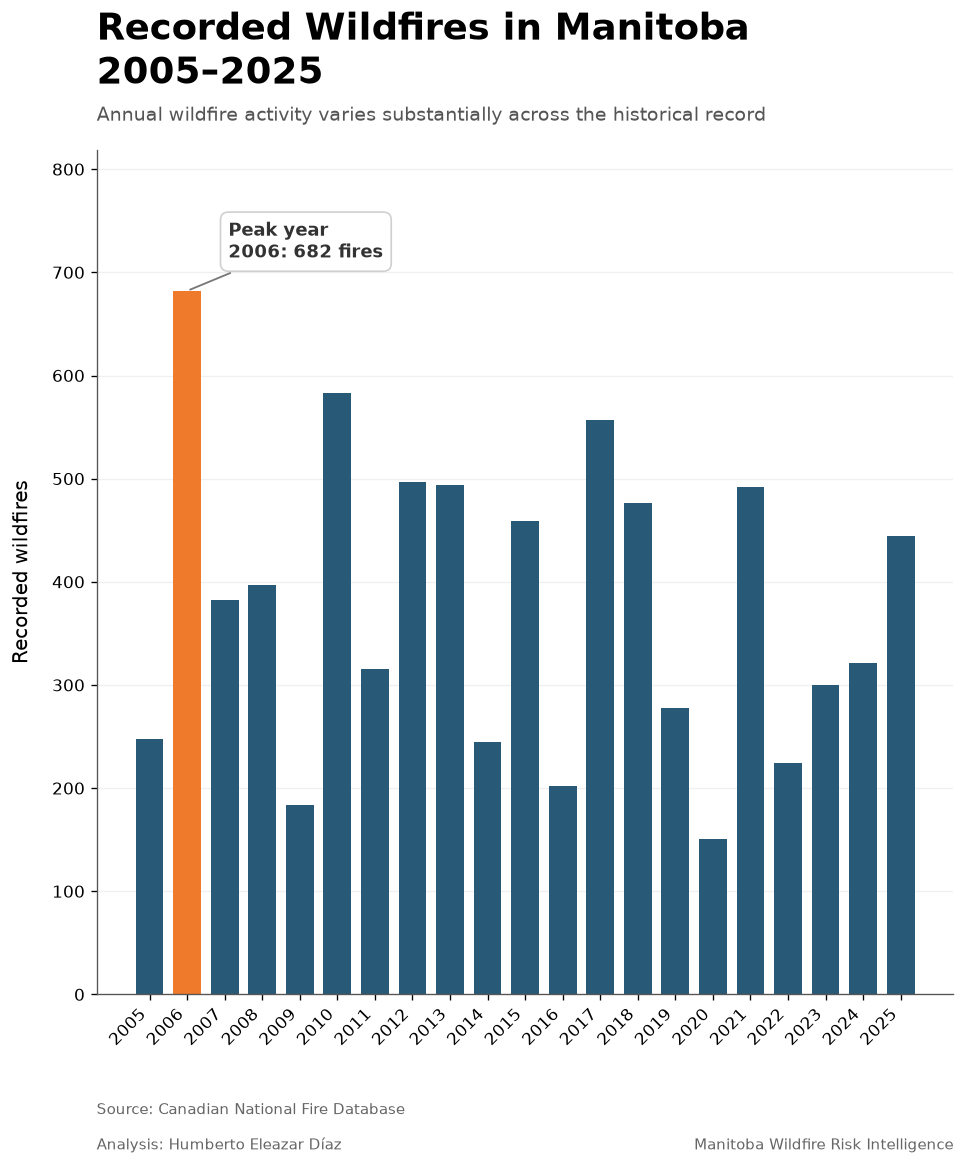

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_annual_wildfires_2005_2025_v3.png


In [7]:
# Identify the peak wildfire year
peak_index = annual_fires["FIRE_COUNT"].idxmax()

peak_position = annual_fires.index.get_loc(
    peak_index
)

peak_year = int(
    annual_fires.loc[
        peak_index,
        "YEAR",
    ]
)

peak_count = int(
    annual_fires.loc[
        peak_index,
        "FIRE_COUNT",
    ]
)

# Create a portrait-style figure for LinkedIn
figure, axis = plt.subplots(
    figsize=(8.5, 10.5)
)

# Reserve dedicated space for the title and footer
figure.subplots_adjust(
    top=0.84,
    bottom=0.17,
    left=0.12,
    right=0.96,
)

# Highlight only the peak year
bar_colors = [
    "#F07A2B"
    if year == peak_year
    else "#285A78"
    for year in annual_fires["YEAR"]
]

bars = axis.bar(
    annual_fires["YEAR"].astype(str),
    annual_fires["FIRE_COUNT"],
    color=bar_colors,
    width=0.74,
    edgecolor="none",
)

# Main title
figure.text(
    0.12,
    0.95,
    "Recorded Wildfires in Manitoba",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

# Title date range
figure.text(
    0.12,
    0.915,
    "2005–2025",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

# Subtitle
figure.text(
    0.12,
    0.875,
    (
        "Annual wildfire activity varies substantially "
        "across the historical record"
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="top",
)

# Axis labels
axis.set_xlabel("")
axis.set_ylabel(
    "Recorded wildfires",
    labelpad=12,
)

# Horizontal gridlines
axis.yaxis.grid(
    True,
    linewidth=0.8,
    alpha=0.18,
)

axis.set_axisbelow(True)

# Give the peak annotation enough vertical space
axis.set_ylim(
    0,
    annual_fires["FIRE_COUNT"].max() * 1.20,
)

# Format year labels
axis.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=10,
)

for label in axis.get_xticklabels():
    label.set_horizontalalignment("right")

axis.tick_params(
    axis="y",
    labelsize=10,
)

# Peak annotation
peak_bar = bars[peak_position]

peak_x = (
    peak_bar.get_x()
    + peak_bar.get_width() / 2
)

peak_y = peak_bar.get_height()

axis.annotate(
    f"Peak year\n{peak_year}: {peak_count:,} fires",
    xy=(
        peak_x,
        peak_y,
    ),
    xytext=(
        peak_x + 1.1,
        peak_y * 1.07,
    ),
    fontsize=10.5,
    fontweight="bold",
    ha="left",
    va="center",
    color="#333333",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": "#D0D0D0",
        "linewidth": 1,
    },
    arrowprops={
        "arrowstyle": "-",
        "color": "#777777",
        "linewidth": 1.1,
    },
)

# Clean axis borders
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.spines["left"].set_color(
    "#555555"
)

axis.spines["bottom"].set_color(
    "#555555"
)

# Footer — separate lines prevent overlap
figure.text(
    0.12,
    0.075,
    "Source: Canadian National Fire Database",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.12,
    0.047,
    "Analysis: Humberto Eleazar Díaz",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.96,
    0.047,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9,
    color="#666666",
    ha="right",
)

# Save the high-resolution LinkedIn image
annual_chart_path = (
    figures_folder
    / "linkedin_annual_wildfires_2005_2025_v3.png"
)

figure.savefig(
    annual_chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", annual_chart_path)

## Monthly Wildfire Seasonality

This figure summarizes how recorded wildfire activity is distributed throughout the year in Manitoba between 2005 and 2025.

In [8]:
month_reference = pd.DataFrame(
    {
        "MONTH": range(1, 13),
        "MONTH_NAME": [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ],
    }
)

monthly_fires = (
    fires
    .assign(
        MONTH=fires["FIRE_DATE"].dt.month
    )
    .groupby(
        "MONTH",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "FIRE_COUNT"
        }
    )
)

monthly_fires = (
    month_reference
    .merge(
        monthly_fires,
        on="MONTH",
        how="left",
    )
    .fillna(
        {
            "FIRE_COUNT": 0
        }
    )
)

monthly_fires["FIRE_COUNT"] = (
    monthly_fires["FIRE_COUNT"]
    .astype(int)
)

fire_season_count = int(
    monthly_fires.loc[
        monthly_fires["MONTH"].between(4, 10),
        "FIRE_COUNT",
    ].sum()
)

total_fire_count = int(
    monthly_fires["FIRE_COUNT"].sum()
)

fire_season_share = (
    fire_season_count
    / total_fire_count
    * 100
)

display(monthly_fires)

print(
    "April–October fires:",
    fire_season_count,
)

print(
    "Share occurring April–October:",
    f"{fire_season_share:.1f}%",
)

,MONTH,MONTH_NAME,FIRE_COUNT
0,1,Jan,0
1,2,Feb,0
2,3,Mar,17
3,4,Apr,517
4,5,May,1217
5,6,Jun,1563
6,7,Jul,2704
7,8,Aug,1408
8,9,Sep,381
9,10,Oct,108


April–October fires: 7898
Share occurring April–October: 99.6%


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


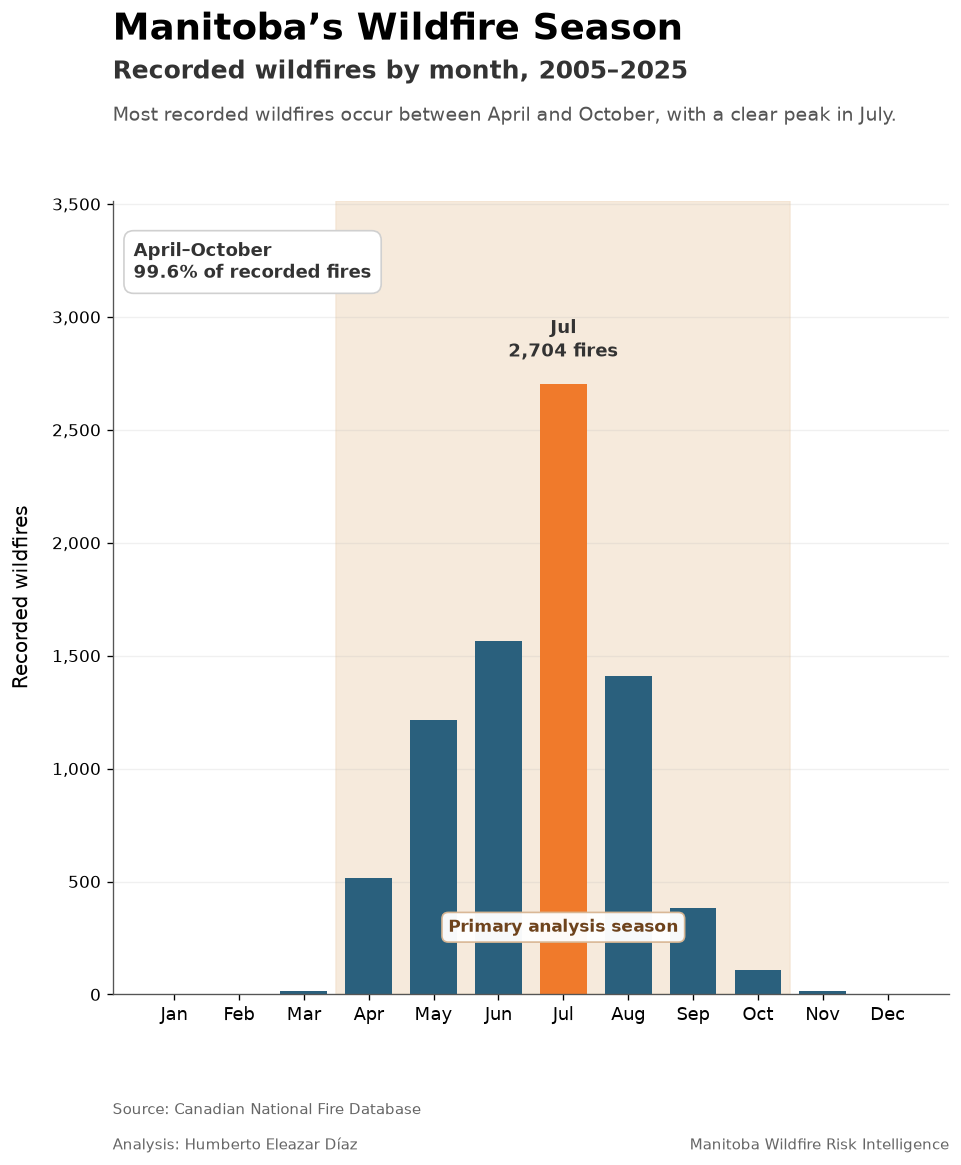

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_monthly_wildfire_seasonality_2005_2025_v3.png


In [9]:
from matplotlib.ticker import StrMethodFormatter

peak_index = monthly_fires["FIRE_COUNT"].idxmax()

peak_position = monthly_fires.index.get_loc(
    peak_index
)

peak_month = monthly_fires.loc[
    peak_index,
    "MONTH_NAME",
]

peak_count = int(
    monthly_fires.loc[
        peak_index,
        "FIRE_COUNT",
    ]
)

x_positions = np.arange(
    len(monthly_fires)
)

figure, axis = plt.subplots(
    figsize=(8.5, 10.5)
)

figure.subplots_adjust(
    top=0.80,
    bottom=0.17,
    left=0.14,
    right=0.96,
)

# Highlight April through October
axis.axvspan(
    2.5,
    9.5,
    color="#F3E2CF",
    alpha=0.72,
    zorder=0,
)

bar_colors = [
    "#F07A2B"
    if position == peak_position
    else "#2A607D"
    for position in x_positions
]

bars = axis.bar(
    x_positions,
    monthly_fires["FIRE_COUNT"],
    color=bar_colors,
    width=0.72,
    edgecolor="none",
    zorder=2,
)

# Title area
figure.text(
    0.14,
    0.95,
    "Manitoba’s Wildfire Season",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

figure.text(
    0.14,
    0.912,
    "Recorded wildfires by month, 2005–2025",
    fontsize=15,
    fontweight="semibold",
    color="#333333",
    ha="left",
    va="top",
)

figure.text(
    0.14,
    0.875,
    (
        "Most recorded wildfires occur between April and October, "
        "with a clear peak in July."
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="top",
)

# Axes
axis.set_xlabel("")

axis.set_ylabel(
    "Recorded wildfires",
    labelpad=12,
)

axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    monthly_fires["MONTH_NAME"],
    fontsize=11,
)

axis.tick_params(
    axis="y",
    labelsize=10,
)

axis.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

axis.yaxis.grid(
    True,
    linewidth=0.8,
    alpha=0.18,
)

axis.set_axisbelow(True)

# Extra room above July bar
axis.set_ylim(
    0,
    peak_count * 1.30,
)

# Simple peak label directly above July
peak_bar = bars[peak_position]

peak_x = (
    peak_bar.get_x()
    + peak_bar.get_width() / 2
)

peak_y = peak_bar.get_height()

axis.text(
    peak_x,
    peak_y + peak_count * 0.035,
    f"{peak_month}\n{peak_count:,} fires",
    fontsize=11,
    fontweight="bold",
    color="#333333",
    ha="center",
    va="bottom",
    linespacing=1.25,
)

# Summary box moved to upper-left
axis.text(
    0.025,
    0.95,
    (
        "April–October\n"
        f"{fire_season_share:.1f}% of recorded fires"
    ),
    transform=axis.transAxes,
    fontsize=10.5,
    fontweight="semibold",
    color="#333333",
    ha="left",
    va="top",
    bbox={
        "boxstyle": "round,pad=0.55",
        "facecolor": "white",
        "edgecolor": "#D0D0D0",
        "linewidth": 1,
    },
    zorder=4,
)

# Fire-season label near the bottom
axis.text(
    6,
    peak_count * 0.11,
    "Primary analysis season",
    fontsize=10,
    fontweight="semibold",
    color="#6E431C",
    ha="center",
    va="center",
    bbox={
        "boxstyle": "round,pad=0.38",
        "facecolor": "white",
        "edgecolor": "#D8B693",
        "linewidth": 1,
        "alpha": 0.97,
    },
    zorder=4,
)

# Clean borders
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

axis.spines["left"].set_color(
    "#555555"
)

axis.spines["bottom"].set_color(
    "#555555"
)

# Footer
figure.text(
    0.14,
    0.075,
    "Source: Canadian National Fire Database",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.14,
    0.047,
    "Analysis: Humberto Eleazar Díaz",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.96,
    0.047,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9,
    color="#666666",
    ha="right",
)

monthly_chart_path = (
    figures_folder
    / "linkedin_monthly_wildfire_seasonality_2005_2025_v3.png"
)

figure.savefig(
    monthly_chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", monthly_chart_path)

## Historical Wildfire Hotspots

This map summarizes the spatial distribution of recorded Manitoba wildfires from 2005 through 2025. Each 10-km grid cell is coloured according to its historical number of wildfire records.

In [10]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter


grid_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_grid_10km.parquet"
)

fires_with_grid_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_with_grid_2005_2025.parquet"
)

boundary_path = (
    project_root
    / "data"
    / "raw"
    / "boundaries"
    / "manitoba_provincial_boundary.geojson"
)

grid = gpd.read_parquet(
    grid_path
)

fires_with_grid = gpd.read_parquet(
    fires_with_grid_path
)

manitoba_boundary = gpd.read_file(
    boundary_path
)

# Work in a projected coordinate system measured in metres
grid = grid.to_crs("EPSG:3347")

manitoba_boundary = manitoba_boundary.to_crs(
    grid.crs
)

fire_counts_by_grid = (
    fires_with_grid
    .groupby(
        "GRID_ID",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "HISTORICAL_FIRE_COUNT"
        }
    )
)

hotspot_grid = grid.merge(
    fire_counts_by_grid,
    on="GRID_ID",
    how="left",
    validate="one_to_one",
)

hotspot_grid["HISTORICAL_FIRE_COUNT"] = (
    hotspot_grid["HISTORICAL_FIRE_COUNT"]
    .fillna(0)
    .astype(int)
)

cells_with_fires = int(
    (
        hotspot_grid["HISTORICAL_FIRE_COUNT"]
        > 0
    ).sum()
)

total_grid_fires = int(
    hotspot_grid["HISTORICAL_FIRE_COUNT"].sum()
)

maximum_cell_count = int(
    hotspot_grid["HISTORICAL_FIRE_COUNT"].max()
)

positive_hotspots = hotspot_grid.loc[
    hotspot_grid["HISTORICAL_FIRE_COUNT"] > 0
].copy()

print("Grid cells:", len(hotspot_grid))
print("Cells with at least one fire:", cells_with_fires)
print("Fires represented:", total_grid_fires)
print("Maximum fires in one cell:", maximum_cell_count)

display(
    hotspot_grid[
        [
            "GRID_ID",
            "HISTORICAL_FIRE_COUNT",
        ]
    ]
    .sort_values(
        "HISTORICAL_FIRE_COUNT",
        ascending=False,
    )
    .head(10)
)

Grid cells: 6501
Cells with at least one fire: 2593
Fires represented: 7915
Maximum fires in one cell: 140


,GRID_ID,HISTORICAL_FIRE_COUNT
4652,MB_080_044,140
2450,MB_076_026,87
5442,MB_061_053,79
2160,MB_032_024,75
3171,MB_063_032,65
3512,MB_038_035,61
759,MB_078_012,59
5360,MB_053_052,51
4702,MB_008_045,50
2037,MB_031_023,50


Top 1% hotspot threshold: 27 fires
Top hotspot cells: 26


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


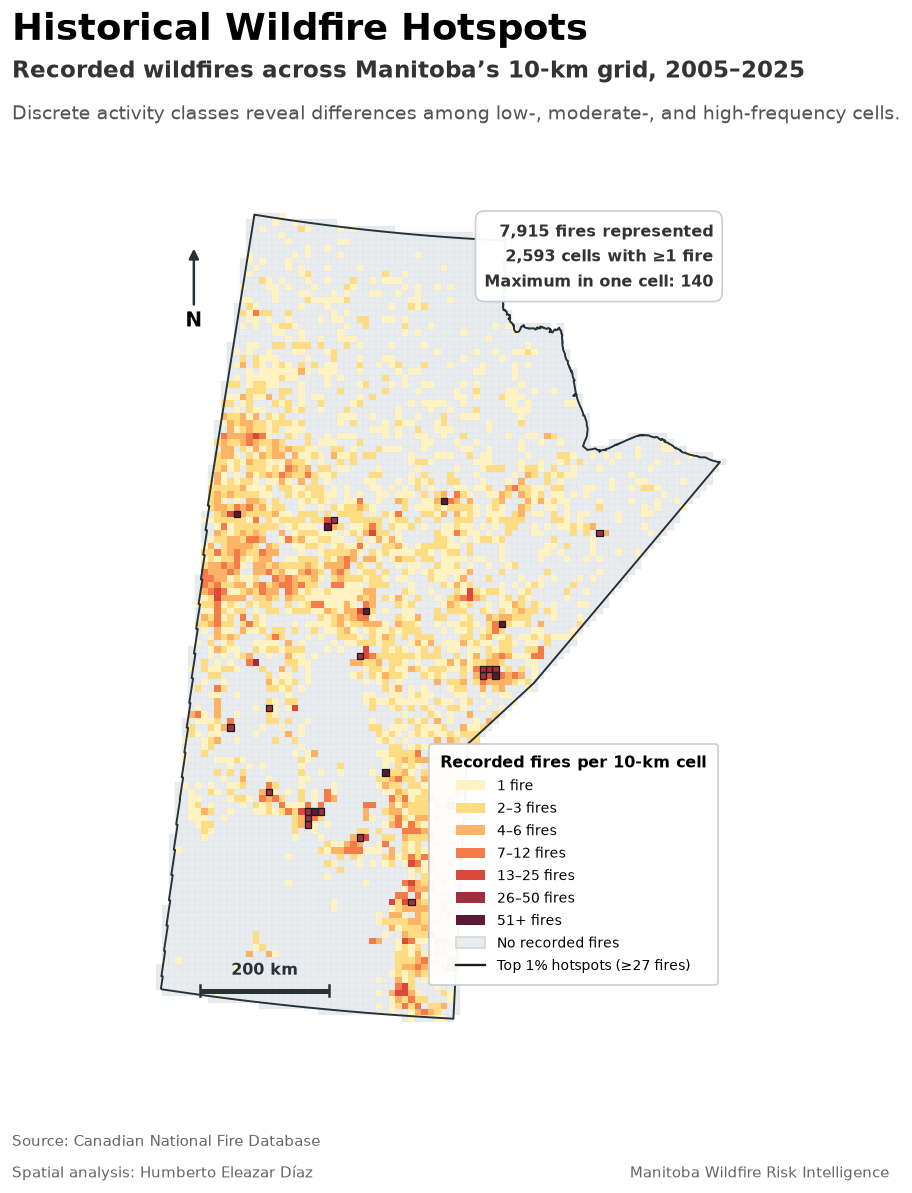

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_manitoba_wildfire_hotspots_sensitive_2005_2025.png


In [11]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# Discrete classes emphasize differences among low- and medium-count cells
class_boundaries = [
    1,
    2,
    4,
    7,
    13,
    26,
    51,
    maximum_cell_count + 1,
]

class_labels = [
    "1 fire",
    "2–3 fires",
    "4–6 fires",
    "7–12 fires",
    "13–25 fires",
    "26–50 fires",
    "51+ fires",
]

class_colors = [
    "#FFF3C4",
    "#FDDC83",
    "#FDB366",
    "#F57C4A",
    "#D94A3A",
    "#9E2F3D",
    "#5B1935",
]

hotspot_cmap = ListedColormap(
    class_colors
)

hotspot_norm = BoundaryNorm(
    class_boundaries,
    hotspot_cmap.N,
)

# Outline the highest-activity 1% of positive cells
top_hotspot_threshold = int(
    np.ceil(
        positive_hotspots[
            "HISTORICAL_FIRE_COUNT"
        ].quantile(0.99)
    )
)

top_hotspots = positive_hotspots.loc[
    positive_hotspots[
        "HISTORICAL_FIRE_COUNT"
    ]
    >= top_hotspot_threshold
].copy()

print(
    "Top 1% hotspot threshold:",
    top_hotspot_threshold,
    "fires",
)

print(
    "Top hotspot cells:",
    len(top_hotspots),
)


figure, axis = plt.subplots(
    figsize=(8.5, 10.5)
)

figure.subplots_adjust(
    top=0.81,
    bottom=0.14,
    left=0.06,
    right=0.94,
)

axis.set_facecolor(
    "#F7F8F9"
)

# Grid cells without recorded wildfire activity
hotspot_grid.plot(
    ax=axis,
    color="#E8ECEF",
    edgecolor="#D3D8DC",
    linewidth=0.07,
    zorder=1,
)

# Positive wildfire cells using sensitive discrete classes
positive_hotspots.plot(
    ax=axis,
    column="HISTORICAL_FIRE_COUNT",
    cmap=hotspot_cmap,
    norm=hotspot_norm,
    edgecolor="none",
    zorder=2,
)

# Highlight the top 1% of hotspot cells
top_hotspots.boundary.plot(
    ax=axis,
    color="#1D1D1D",
    linewidth=0.75,
    zorder=3,
)

# Provincial outline
manitoba_boundary.boundary.plot(
    ax=axis,
    color="#263238",
    linewidth=1.15,
    zorder=4,
)

# Map bounds with small margins
min_x, min_y, max_x, max_y = (
    manitoba_boundary.total_bounds
)

map_width = max_x - min_x
map_height = max_y - min_y

axis.set_xlim(
    min_x - map_width * 0.025,
    max_x + map_width * 0.025,
)

axis.set_ylim(
    min_y - map_height * 0.025,
    max_y + map_height * 0.025,
)

# Title block
figure.text(
    0.08,
    0.955,
    "Historical Wildfire Hotspots",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

figure.text(
    0.08,
    0.917,
    "Recorded wildfires across Manitoba’s 10-km grid, 2005–2025",
    fontsize=14,
    fontweight="semibold",
    color="#333333",
    ha="left",
    va="top",
)

figure.text(
    0.08,
    0.881,
    (
        "Discrete activity classes reveal differences among "
        "low-, moderate-, and high-frequency cells."
    ),
    fontsize=11.2,
    color="#555555",
    ha="left",
    va="top",
)

# Summary box
axis.text(
    0.965,
    0.97,
    (
        f"{total_grid_fires:,} fires represented\n"
        f"{cells_with_fires:,} cells with ≥1 fire\n"
        f"Maximum in one cell: {maximum_cell_count:,}"
    ),
    transform=axis.transAxes,
    fontsize=9.7,
    fontweight="semibold",
    color="#333333",
    ha="right",
    va="top",
    linespacing=1.5,
    bbox={
        "boxstyle": "round,pad=0.55",
        "facecolor": "white",
        "edgecolor": "#C7CCD0",
        "linewidth": 1,
        "alpha": 0.96,
    },
    zorder=6,
)

# North arrow
axis.annotate(
    "N",
    xy=(0.08, 0.94),
    xytext=(0.08, 0.85),
    xycoords="axes fraction",
    textcoords="axes fraction",
    fontsize=12,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops={
        "arrowstyle": "-|>",
        "color": "#263238",
        "linewidth": 1.5,
    },
    zorder=6,
)

# Scale bar
scale_length_km = 200
scale_length_m = scale_length_km * 1000

scale_x = min_x + map_width * 0.07
scale_y = min_y + map_height * 0.035

axis.plot(
    [
        scale_x,
        scale_x + scale_length_m,
    ],
    [
        scale_y,
        scale_y,
    ],
    color="#263238",
    linewidth=3,
    solid_capstyle="butt",
    zorder=6,
)

axis.plot(
    [
        scale_x,
        scale_x,
    ],
    [
        scale_y - map_height * 0.007,
        scale_y + map_height * 0.007,
    ],
    color="#263238",
    linewidth=1.5,
    zorder=6,
)

axis.plot(
    [
        scale_x + scale_length_m,
        scale_x + scale_length_m,
    ],
    [
        scale_y - map_height * 0.007,
        scale_y + map_height * 0.007,
    ],
    color="#263238",
    linewidth=1.5,
    zorder=6,
)

axis.text(
    scale_x + scale_length_m / 2,
    scale_y + map_height * 0.015,
    f"{scale_length_km} km",
    fontsize=9.5,
    fontweight="semibold",
    color="#263238",
    ha="center",
    va="bottom",
    zorder=6,
)

# Discrete legend
legend_handles = [
    Patch(
        facecolor=color,
        edgecolor="none",
        label=label,
    )
    for color, label in zip(
        class_colors,
        class_labels,
    )
]

legend_handles.append(
    Patch(
        facecolor="#E8ECEF",
        edgecolor="#D3D8DC",
        label="No recorded fires",
    )
)

legend_handles.append(
    Line2D(
        [0],
        [0],
        color="#1D1D1D",
        linewidth=1.4,
        label=(
            f"Top 1% hotspots "
            f"(≥{top_hotspot_threshold} fires)"
        ),
    )
)

legend = axis.legend(
    handles=legend_handles,
    title="Recorded fires per 10-km cell",
    loc="lower right",
    bbox_to_anchor=(0.985, 0.055),
    fontsize=8.7,
    title_fontsize=9.5,
    frameon=True,
    framealpha=0.96,
    facecolor="white",
    edgecolor="#C7CCD0",
    borderpad=0.8,
    labelspacing=0.55,
)

legend.get_title().set_fontweight(
    "semibold"
)

# Clean map
axis.set_axis_off()
axis.set_aspect("equal")

# Footer
figure.text(
    0.08,
    0.055,
    "Source: Canadian National Fire Database",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.08,
    0.030,
    "Spatial analysis: Humberto Eleazar Díaz",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.94,
    0.030,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9,
    color="#666666",
    ha="right",
)

sensitive_hotspot_map_path = (
    figures_folder
    / "linkedin_manitoba_wildfire_hotspots_sensitive_2005_2025.png"
)

figure.savefig(
    sensitive_hotspot_map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    "Saved:",
    sensitive_hotspot_map_path,
)

## Recorded Wildfires by Cause

This figure summarizes the recorded causes of Manitoba wildfires included in the spatial modelling dataset from 2005 through 2025.

In [12]:
targets_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_daily_fire_targets_2005_2025.parquet"
)

fire_targets = pd.read_parquet(
    targets_path
)

cause_summary = pd.DataFrame(
    {
        "CAUSE": [
            "Natural",
            "Human",
            "Unknown",
        ],
        "FIRE_COUNT": [
            int(
                fire_targets[
                    "NATURAL_FIRE_COUNT"
                ].sum()
            ),
            int(
                fire_targets[
                    "HUMAN_FIRE_COUNT"
                ].sum()
            ),
            int(
                fire_targets[
                    "UNKNOWN_FIRE_COUNT"
                ].sum()
            ),
        ],
    }
)

total_cause_fires = int(
    cause_summary["FIRE_COUNT"].sum()
)

cause_summary["PERCENTAGE"] = (
    cause_summary["FIRE_COUNT"]
    / total_cause_fires
    * 100
)

cause_summary = (
    cause_summary
    .sort_values(
        "FIRE_COUNT",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(cause_summary)

print(
    "Total fires represented:",
    total_cause_fires,
)

,CAUSE,FIRE_COUNT,PERCENTAGE
0,Natural,4645,58.686039
1,Human,3253,41.099179
2,Unknown,17,0.214782


Total fires represented: 7915


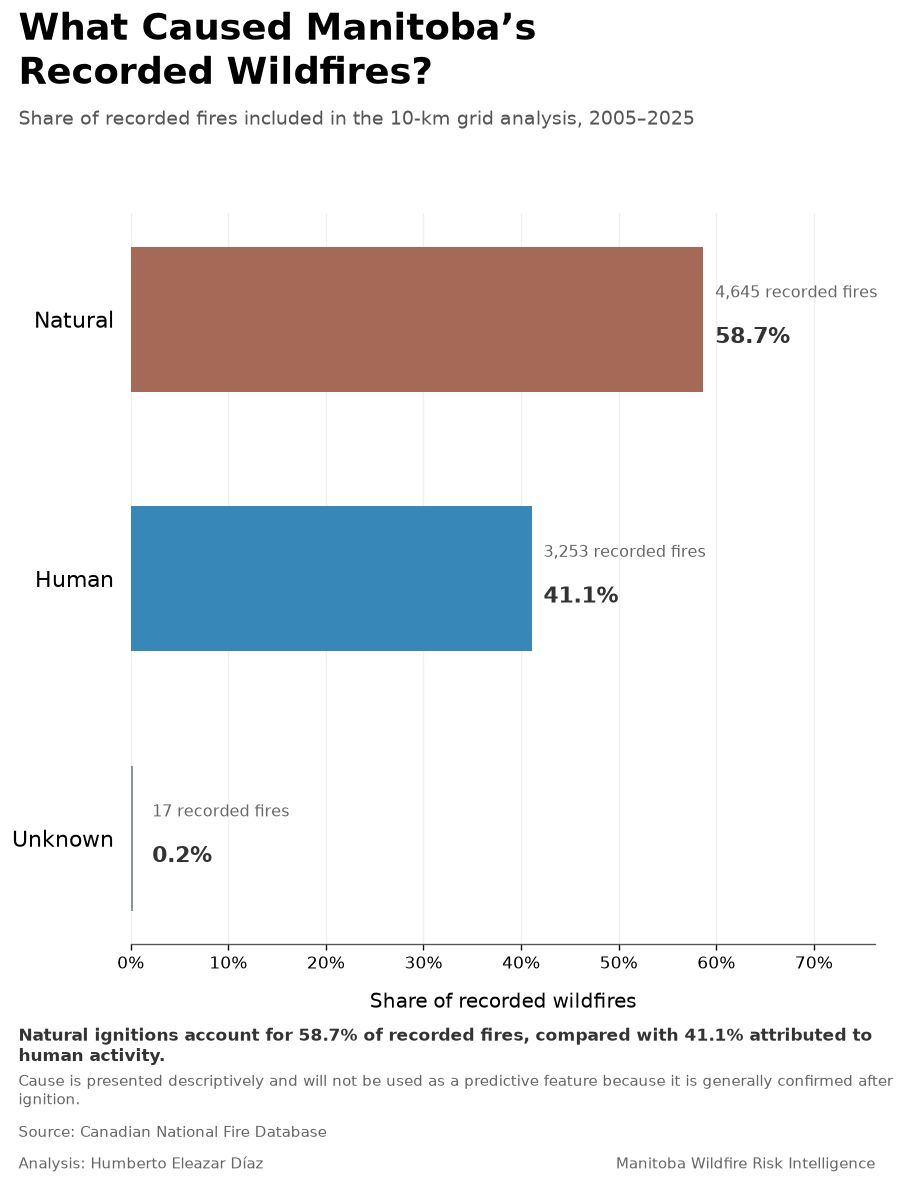

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_manitoba_wildfire_cause_percentages_2005_2025.png


In [13]:
from matplotlib.ticker import PercentFormatter


cause_colors = {
    "Natural": "#A56A57",
    "Human": "#3788B8",
    "Unknown": "#8A949A",
}

bar_colors = [
    cause_colors[cause]
    for cause in cause_summary["CAUSE"]
]

figure, axis = plt.subplots(
    figsize=(8.5, 10.5)
)

figure.subplots_adjust(
    top=0.79,
    bottom=0.21,
    left=0.21,
    right=0.94,
)

# Bars represent percentage of all recorded fires
bars = axis.barh(
    cause_summary["CAUSE"],
    cause_summary["PERCENTAGE"],
    color=bar_colors,
    height=0.56,
    edgecolor="none",
)

# Largest category appears at the top
axis.invert_yaxis()

# Title block
figure.text(
    0.10,
    0.95,
    "What Caused Manitoba’s",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

figure.text(
    0.10,
    0.915,
    "Recorded Wildfires?",
    fontsize=22,
    fontweight="bold",
    ha="left",
    va="top",
)

figure.text(
    0.10,
    0.872,
    (
        "Share of recorded fires included in the "
        "10-km grid analysis, 2005–2025"
    ),
    fontsize=11.5,
    color="#555555",
    ha="left",
    va="top",
)

# Axis styling
axis.set_xlabel(
    "Share of recorded wildfires",
    labelpad=12,
)

axis.set_ylabel("")

axis.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=0,
    )
)

axis.xaxis.grid(
    True,
    linewidth=0.8,
    alpha=0.18,
)

axis.set_axisbelow(True)

axis.tick_params(
    axis="x",
    labelsize=10,
)

axis.tick_params(
    axis="y",
    labelsize=13,
    length=0,
    pad=10,
)

maximum_percentage = float(
    cause_summary["PERCENTAGE"].max()
)

axis.set_xlim(
    0,
    maximum_percentage * 1.30,
)

# Percentage is emphasized; count is secondary
for bar, row in zip(
    bars,
    cause_summary.itertuples(),
):
    bar_width = float(
        bar.get_width()
    )

    label_x = max(
        bar_width + 1.2,
        2.2,
    )

    label_y = (
        bar.get_y()
        + bar.get_height() / 2
    )

    axis.text(
        label_x,
        label_y + 0.07,
        f"{row.PERCENTAGE:.1f}%",
        fontsize=13,
        fontweight="bold",
        color="#333333",
        ha="left",
        va="center",
    )

    axis.text(
        label_x,
        label_y - 0.10,
        f"{row.FIRE_COUNT:,} recorded fires",
        fontsize=9.5,
        color="#666666",
        ha="left",
        va="center",
    )

natural_percentage = float(
    cause_summary.loc[
        cause_summary["CAUSE"] == "Natural",
        "PERCENTAGE",
    ].iloc[0]
)

human_percentage = float(
    cause_summary.loc[
        cause_summary["CAUSE"] == "Human",
        "PERCENTAGE",
    ].iloc[0]
)

# Main takeaway beneath the chart
figure.text(
    0.10,
    0.145,
    (
        f"Natural ignitions account for {natural_percentage:.1f}% "
        f"of recorded fires, compared with "
        f"{human_percentage:.1f}% attributed to human activity."
    ),
    fontsize=10,
    fontweight="semibold",
    color="#333333",
    ha="left",
    va="top",
    wrap=True,
)

# Methodological note
figure.text(
    0.10,
    0.108,
    (
        "Cause is presented descriptively and will not be used as a "
        "predictive feature because it is generally confirmed after ignition."
    ),
    fontsize=9.2,
    color="#666666",
    ha="left",
    va="top",
    wrap=True,
)

# Clean borders
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

axis.spines["bottom"].set_color(
    "#555555"
)

# Footer
figure.text(
    0.10,
    0.057,
    "Source: Canadian National Fire Database",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.10,
    0.032,
    "Analysis: Humberto Eleazar Díaz",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.94,
    0.032,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9,
    color="#666666",
    ha="right",
)

cause_chart_path = (
    figures_folder
    / "linkedin_manitoba_wildfire_cause_percentages_2005_2025.png"
)

figure.savefig(
    cause_chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", cause_chart_path)

## Spatial Patterns by Wildfire Cause

This map compares recorded human-caused and natural wildfires in Manitoba and highlights major population centres to support visual interpretation.

In [14]:
# Use the cleaned fire dataset already loaded earlier as `fires`
# and the Manitoba boundary already loaded earlier as `manitoba_boundary`

cause_map_fires = fires.copy()

# Keep the main cause categories
cause_map_fires = cause_map_fires.loc[
    cause_map_fires["CAUSE_LABEL"].isin(
        ["Human", "Natural", "Unknown"]
    )
].copy()

# Reproject to a metric CRS for cleaner map work
cause_map_fires = cause_map_fires.to_crs("EPSG:3347")
cause_map_boundary = manitoba_boundary.to_crs("EPSG:3347")

# Approximate major Manitoba population centres
population_centres = pd.DataFrame(
    {
        "PLACE": [
            "Winnipeg",
            "Brandon",
            "Steinbach",
            "Portage la Prairie",
            "Thompson",
            "The Pas",
            "Dauphin",
            "Selkirk",
            "Winkler",
            "Morden",
            "Flin Flon",
        ],
        "LONGITUDE": [
            -97.1384,
            -99.9501,
            -96.6845,
            -98.2923,
            -97.8642,
            -101.2541,
            -100.0502,
            -96.8845,
            -97.9410,
            -98.1018,
            -101.2445,
        ],
        "LATITUDE": [
            49.8951,
            49.8485,
            49.5258,
            49.9728,
            55.7435,
            53.8256,
            51.1494,
            50.1436,
            49.1817,
            49.1919,
            54.7682,
        ],
    }
)

population_centres = gpd.GeoDataFrame(
    population_centres,
    geometry=gpd.points_from_xy(
        population_centres["LONGITUDE"],
        population_centres["LATITUDE"],
    ),
    crs="EPSG:4326",
).to_crs("EPSG:3347")

print("Fire records in map:", len(cause_map_fires))
print(
    cause_map_fires["CAUSE_LABEL"]
    .value_counts()
)
print("Population centres:", len(population_centres))

Fire records in map: 7931
CAUSE_LABEL
Natural    4659
Human      3255
Unknown      17
Name: count, dtype: int64
Population centres: 11


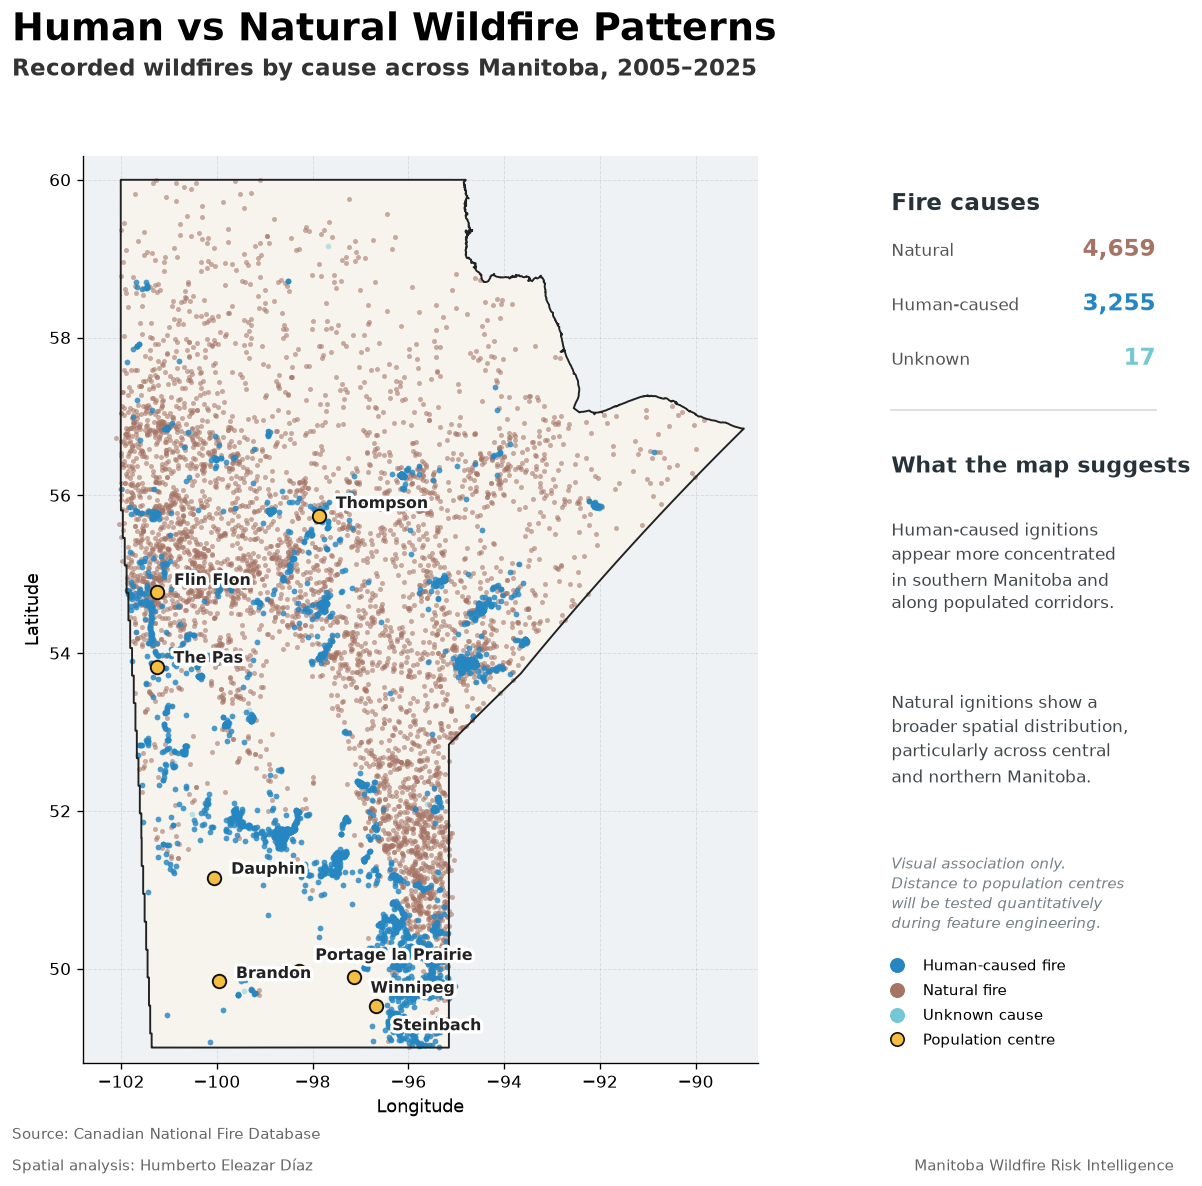

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_manitoba_wildfire_causes_spatial_2005_2025_v6.png


In [15]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec


# ===============================================================
# PREPARE DATA
# ===============================================================

cause_map_fires = fires.copy()

cause_map_fires = cause_map_fires.loc[
    cause_map_fires["CAUSE_LABEL"].isin(
        ["Human", "Natural", "Unknown"]
    )
].copy()

cause_map_fires = cause_map_fires.to_crs(
    "EPSG:4326"
)

cause_map_boundary = manitoba_boundary.to_crs(
    "EPSG:4326"
)

# Selected Manitoba population centres
population_centres = pd.DataFrame(
    {
        "PLACE": [
            "Winnipeg",
            "Brandon",
            "Steinbach",
            "Portage la Prairie",
            "Thompson",
            "The Pas",
            "Dauphin",
            "Flin Flon",
        ],
        "LONGITUDE": [
            -97.1384,
            -99.9501,
            -96.6845,
            -98.2923,
            -97.8642,
            -101.2541,
            -100.0502,
            -101.2445,
        ],
        "LATITUDE": [
            49.8951,
            49.8485,
            49.5258,
            49.9728,
            55.7435,
            53.8256,
            51.1494,
            54.7682,
        ],
    }
)

population_centres = gpd.GeoDataFrame(
    population_centres,
    geometry=gpd.points_from_xy(
        population_centres["LONGITUDE"],
        population_centres["LATITUDE"],
    ),
    crs="EPSG:4326",
)

natural_fires = cause_map_fires.loc[
    cause_map_fires["CAUSE_LABEL"] == "Natural"
].copy()

human_fires = cause_map_fires.loc[
    cause_map_fires["CAUSE_LABEL"] == "Human"
].copy()

unknown_fires = cause_map_fires.loc[
    cause_map_fires["CAUSE_LABEL"] == "Unknown"
].copy()

human_count = len(human_fires)
natural_count = len(natural_fires)
unknown_count = len(unknown_fires)

known_total = (
    human_count
    + natural_count
)

human_pct = (
    human_count
    / known_total
    * 100
)

natural_pct = (
    natural_count
    / known_total
    * 100
)


# ===============================================================
# FIGURE LAYOUT
# ===============================================================

figure = plt.figure(
    figsize=(11, 10.5),
    facecolor="white",
)

grid_spec = GridSpec(
    nrows=1,
    ncols=2,
    figure=figure,
    width_ratios=[
        3.4,
        1.25,
    ],
    wspace=0.08,
)

map_axis = figure.add_subplot(
    grid_spec[0, 0]
)

sidebar_axis = figure.add_subplot(
    grid_spec[0, 1]
)

figure.subplots_adjust(
    top=0.84,
    bottom=0.12,
    left=0.08,
    right=0.96,
)


# ===============================================================
# MAP
# ===============================================================

map_axis.set_facecolor(
    "#EEF2F5"
)

# Manitoba fill
cause_map_boundary.plot(
    ax=map_axis,
    color="#F7F4EE",
    edgecolor="none",
    zorder=1,
)

# Natural fires
natural_fires.plot(
    ax=map_axis,
    color="#A57465",
    markersize=9,
    alpha=0.58,
    linewidth=0,
    zorder=2,
)

# Human-caused fires
human_fires.plot(
    ax=map_axis,
    color="#2586C1",
    markersize=12,
    alpha=0.82,
    linewidth=0,
    zorder=3,
)

# Unknown
if len(unknown_fires) > 0:

    unknown_fires.plot(
        ax=map_axis,
        color="#74C7D5",
        markersize=12,
        alpha=0.45,
        linewidth=0,
        zorder=2.5,
    )

# Manitoba border
cause_map_boundary.boundary.plot(
    ax=map_axis,
    color="#222222",
    linewidth=1.15,
    zorder=4,
)


# ===============================================================
# POPULATION CENTRES
# ===============================================================

population_centres.plot(
    ax=map_axis,
    color="#F4BE41",
    edgecolor="#111111",
    markersize=65,
    linewidth=1.15,
    zorder=5,
)

# Manual offsets keep labels separated
label_offsets = {
    "Winnipeg": (10, -7),
    "Brandon": (10, 4),
    "Steinbach": (10, -12),
    "Portage la Prairie": (10, 9),
    "Thompson": (10, 7),
    "The Pas": (10, 5),
    "Dauphin": (10, 5),
    "Flin Flon": (10, 7),
}

for row in population_centres.itertuples():

    offset_x, offset_y = (
        label_offsets[row.PLACE]
    )

    label = map_axis.annotate(
        row.PLACE,
        xy=(
            row.geometry.x,
            row.geometry.y,
        ),
        xytext=(
            offset_x,
            offset_y,
        ),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="semibold",
        color="#222222",
        ha="left",
        va="center",
        zorder=6,
    )

    # Strong white halo
    label.set_path_effects(
        [
            pe.Stroke(
                linewidth=4,
                foreground="white",
            ),
            pe.Normal(),
        ]
    )


# ===============================================================
# COORDINATES
# ===============================================================

map_axis.set_xlim(
    -102.8,
    -88.7,
)

map_axis.set_ylim(
    48.8,
    60.3,
)

map_axis.set_xticks(
    np.arange(
        -102,
        -88,
        2,
    )
)

map_axis.set_yticks(
    np.arange(
        50,
        61,
        2,
    )
)

map_axis.set_xlabel(
    "Longitude",
    fontsize=11,
)

map_axis.set_ylabel(
    "Latitude",
    fontsize=11,
)

map_axis.tick_params(
    labelsize=10,
)

map_axis.grid(
    True,
    linestyle="--",
    linewidth=0.55,
    alpha=0.22,
    color="#7F8C8D",
)

map_axis.set_axisbelow(True)


# ===============================================================
# TITLE
# ===============================================================

figure.text(
    0.08,
    0.955,
    "Human vs Natural Wildfire Patterns",
    fontsize=23,
    fontweight="bold",
    ha="left",
    va="top",
)

figure.text(
    0.08,
    0.918,
    (
        "Recorded wildfires by cause "
        "across Manitoba, 2005–2025"
    ),
    fontsize=14,
    fontweight="semibold",
    color="#333333",
    ha="left",
    va="top",
)


# ===============================================================
# RIGHT SIDEBAR
# ===============================================================

sidebar_axis.set_facecolor(
    "#F7F8F9"
)

sidebar_axis.set_xlim(
    0,
    1,
)

sidebar_axis.set_ylim(
    0,
    1,
)

sidebar_axis.axis(
    "off"
)


# ---------------------------------------------------------------
# Sidebar heading
# ---------------------------------------------------------------

sidebar_axis.text(
    0.06,
    0.96,
    "Fire causes",
    fontsize=14,
    fontweight="bold",
    color="#263238",
    ha="left",
    va="top",
)


# ---------------------------------------------------------------
# Cause statistics
# ---------------------------------------------------------------

sidebar_axis.text(
    0.06,
    0.89,
    "Natural",
    fontsize=10,
    color="#555555",
    ha="left",
)

sidebar_axis.text(
    0.94,
    0.89,
    f"{natural_count:,}",
    fontsize=14,
    fontweight="bold",
    color="#A57465",
    ha="right",
)

sidebar_axis.text(
    0.06,
    0.83,
    "Human-caused",
    fontsize=10,
    color="#555555",
    ha="left",
)

sidebar_axis.text(
    0.94,
    0.83,
    f"{human_count:,}",
    fontsize=14,
    fontweight="bold",
    color="#2586C1",
    ha="right",
)

sidebar_axis.text(
    0.06,
    0.77,
    "Unknown",
    fontsize=10,
    color="#555555",
    ha="left",
)

sidebar_axis.text(
    0.94,
    0.77,
    f"{unknown_count:,}",
    fontsize=14,
    fontweight="bold",
    color="#74C7D5",
    ha="right",
)

# Divider
sidebar_axis.plot(
    [0.06, 0.94],
    [0.72, 0.72],
    color="#D5DADD",
    linewidth=1,
)


# ---------------------------------------------------------------
# Interpretation
# ---------------------------------------------------------------

sidebar_axis.text(
    0.06,
    0.67,
    "What the map suggests",
    fontsize=13,
    fontweight="bold",
    color="#263238",
    ha="left",
    va="top",
)

sidebar_axis.text(
    0.06,
    0.60,
    (
        "Human-caused ignitions\n"
        "appear more concentrated\n"
        "in southern Manitoba and\n"
        "along populated corridors."
    ),
    fontsize=10,
    color="#40484D",
    ha="left",
    va="top",
    linespacing=1.45,
)

sidebar_axis.text(
    0.06,
    0.41,
    (
        "Natural ignitions show a\n"
        "broader spatial distribution,\n"
        "particularly across central\n"
        "and northern Manitoba."
    ),
    fontsize=10,
    color="#40484D",
    ha="left",
    va="top",
    linespacing=1.45,
)

sidebar_axis.text(
    0.06,
    0.23,
    (
        "Visual association only.\n"
        "Distance to population centres\n"
        "will be tested quantitatively\n"
        "during feature engineering."
    ),
    fontsize=8.8,
    style="italic",
    color="#758087",
    ha="left",
    va="top",
    linespacing=1.35,
)


# ===============================================================
# LEGEND — INSIDE SIDEBAR ONLY
# ===============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        label="Human-caused fire",
        markerfacecolor="#2586C1",
        markeredgecolor="none",
        markersize=9,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        label="Natural fire",
        markerfacecolor="#A57465",
        markeredgecolor="none",
        markersize=9,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        label="Unknown cause",
        markerfacecolor="#74C7D5",
        markeredgecolor="none",
        markersize=9,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        label="Population centre",
        markerfacecolor="#F4BE41",
        markeredgecolor="#111111",
        markersize=8,
    ),
]

sidebar_axis.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(
        0.01,
        0.01,
    ),
    frameon=False,
    fontsize=9,
    borderaxespad=0,
    handletextpad=0.7,
    labelspacing=0.65,
)


# ===============================================================
# FOOTER
# ===============================================================

figure.text(
    0.08,
    0.060,
    "Source: Canadian National Fire Database",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.08,
    0.035,
    "Spatial analysis: Humberto Eleazar Díaz",
    fontsize=9,
    color="#666666",
    ha="left",
)

figure.text(
    0.96,
    0.035,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9,
    color="#666666",
    ha="right",
)


# ===============================================================
# SAVE
# ===============================================================

cause_spatial_map_path = (
    figures_folder
    / "linkedin_manitoba_wildfire_causes_spatial_2005_2025_v6.png"
)

figure.savefig(
    cause_spatial_map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    "Saved:",
    cause_spatial_map_path,
)

## Project Workflow

This figure summarizes the main analytical workflow behind the Manitoba Wildfire Risk Intelligence project, from historical wildfire records to a model-ready wildfire risk table.

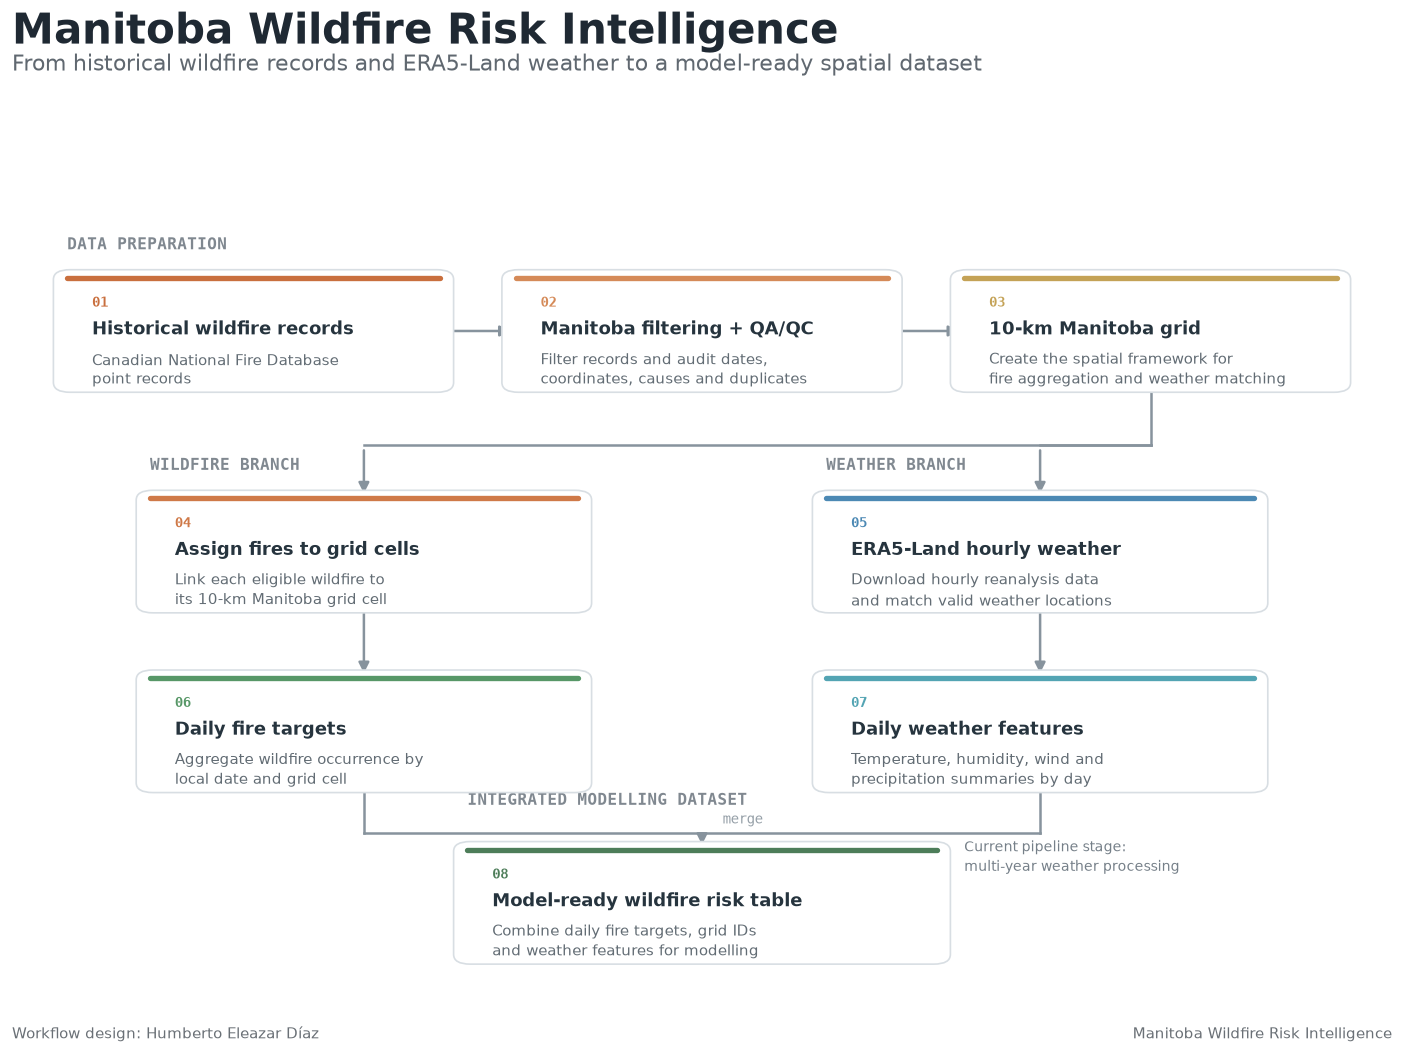

Saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/outputs/figures/linkedin/linkedin_project_workflow_manitoba_wildfire_risk_intelligence_rstudio_v2.png


In [23]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ============================================================
# WORKFLOW CONTENT
# ============================================================

steps = [
    {
        "id": "01",
        "title": "Historical wildfire records",
        "subtitle": (
            "Canadian National Fire Database\n"
            "point records"
        ),
        "color": "#C96F3E",
        "xy": (0.04, 0.74),
        "w": 0.27,
        "h": 0.13,
    },
    {
        "id": "02",
        "title": "Manitoba filtering + QA/QC",
        "subtitle": (
            "Filter records and audit dates,\n"
            "coordinates, causes and duplicates"
        ),
        "color": "#D58A58",
        "xy": (0.365, 0.74),
        "w": 0.27,
        "h": 0.13,
    },
    {
        "id": "03",
        "title": "10-km Manitoba grid",
        "subtitle": (
            "Create the spatial framework for\n"
            "fire aggregation and weather matching"
        ),
        "color": "#C4A256",
        "xy": (0.69, 0.74),
        "w": 0.27,
        "h": 0.13,
    },
    {
        "id": "04",
        "title": "Assign fires to grid cells",
        "subtitle": (
            "Link each eligible wildfire to\n"
            "its 10-km Manitoba grid cell"
        ),
        "color": "#CF7948",
        "xy": (0.10, 0.47),
        "w": 0.31,
        "h": 0.13,
    },
    {
        "id": "05",
        "title": "ERA5-Land hourly weather",
        "subtitle": (
            "Download hourly reanalysis data\n"
            "and match valid weather locations"
        ),
        "color": "#4C89B4",
        "xy": (0.59, 0.47),
        "w": 0.31,
        "h": 0.13,
    },
    {
        "id": "06",
        "title": "Daily fire targets",
        "subtitle": (
            "Aggregate wildfire occurrence by\n"
            "local date and grid cell"
        ),
        "color": "#579767",
        "xy": (0.10, 0.25),
        "w": 0.31,
        "h": 0.13,
    },
    {
        "id": "07",
        "title": "Daily weather features",
        "subtitle": (
            "Temperature, humidity, wind and\n"
            "precipitation summaries by day"
        ),
        "color": "#53A4B3",
        "xy": (0.59, 0.25),
        "w": 0.31,
        "h": 0.13,
    },
    {
        "id": "08",
        "title": "Model-ready wildfire risk table",
        "subtitle": (
            "Combine daily fire targets, grid IDs\n"
            "and weather features for modelling"
        ),
        "color": "#4D7D59",
        "xy": (0.33, 0.04),
        "w": 0.34,
        "h": 0.13,
    },
]


# ============================================================
# CARD FUNCTION
# ============================================================

def draw_card(
    axis,
    step,
):
    x, y = step["xy"]
    w = step["w"]
    h = step["h"]
    color = step["color"]

    # Flat white analytical-report card
    card = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.010,rounding_size=0.012",
        linewidth=1.0,
        edgecolor="#D8DEE3",
        facecolor="#FFFFFF",
        zorder=3,
    )

    axis.add_patch(card)

    # Thin accent line
    axis.plot(
        [x, x + w],
        [y + h, y + h],
        color=color,
        linewidth=3.2,
        solid_capstyle="round",
        zorder=4,
    )

    # Step ID
    axis.text(
        x + 0.018,
        y + h - 0.022,
        step["id"],
        fontsize=8.5,
        fontweight="bold",
        fontfamily="monospace",
        color=color,
        ha="left",
        va="top",
        zorder=5,
    )

    # Title
    axis.text(
        x + 0.018,
        y + h - 0.052,
        step["title"],
        fontsize=11.0,
        fontweight="bold",
        color="#26343E",
        ha="left",
        va="top",
        zorder=5,
    )

    # Subtitle
    axis.text(
        x + 0.018,
        y + h - 0.088,
        step["subtitle"],
        fontsize=8.8,
        color="#626C74",
        ha="left",
        va="top",
        linespacing=1.35,
        zorder=5,
    )


# ============================================================
# POSITION HELPERS
# ============================================================

def left_mid(step):
    x, y = step["xy"]

    return (
        x,
        y + step["h"] / 2,
    )


def right_mid(step):
    x, y = step["xy"]

    return (
        x + step["w"],
        y + step["h"] / 2,
    )


def top_mid(step):
    x, y = step["xy"]

    return (
        x + step["w"] / 2,
        y + step["h"],
    )


def bottom_mid(step):
    x, y = step["xy"]

    return (
        x + step["w"] / 2,
        y,
    )


# ============================================================
# SIMPLE ARROW
# ============================================================

def draw_arrow(
    axis,
    start,
    end,
):
    arrow = FancyArrowPatch(
        posA=start,
        posB=end,
        arrowstyle="-|>",
        mutation_scale=13,
        linewidth=1.5,
        color="#87939D",
        connectionstyle="arc3,rad=0",
        shrinkA=3,
        shrinkB=3,
        zorder=1,
    )

    axis.add_patch(arrow)


# ============================================================
# FIGURE
# ============================================================

figure, axis = plt.subplots(
    figsize=(12.5, 9.2)
)

figure.subplots_adjust(
    top=0.82,
    bottom=0.08,
    left=0.04,
    right=0.96,
)

axis.set_xlim(0, 1)
axis.set_ylim(0, 1)

axis.axis("off")

figure.patch.set_facecolor(
    "#FFFFFF"
)

axis.set_facecolor(
    "#FFFFFF"
)


# ============================================================
# TITLE
# ============================================================

figure.text(
    0.04,
    0.965,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=25,
    fontweight="bold",
    color="#1F2933",
    ha="left",
    va="top",
)

figure.text(
    0.04,
    0.927,
    (
        "From historical wildfire records and ERA5-Land weather "
        "to a model-ready spatial dataset"
    ),
    fontsize=13,
    color="#606870",
    ha="left",
    va="top",
)


# ============================================================
# SECTION LABELS
# ============================================================

section_style = {
    "fontsize": 9.5,
    "fontweight": "bold",
    "fontfamily": "monospace",
    "color": "#808890",
    "ha": "left",
}

axis.text(
    0.04,
    0.905,
    "DATA PREPARATION",
    **section_style,
)

axis.text(
    0.10,
    0.635,
    "WILDFIRE BRANCH",
    **section_style,
)

axis.text(
    0.59,
    0.635,
    "WEATHER BRANCH",
    **section_style,
)

axis.text(
    0.33,
    0.225,
    "INTEGRATED MODELLING DATASET",
    **section_style,
)


# ============================================================
# DRAW CARDS
# ============================================================

for step in steps:
    draw_card(
        axis,
        step,
    )

lookup = {
    step["id"]: step
    for step in steps
}


# ============================================================
# TOP DATA-PREPARATION FLOW
# ============================================================

draw_arrow(
    axis,
    right_mid(lookup["01"]),
    left_mid(lookup["02"]),
)

draw_arrow(
    axis,
    right_mid(lookup["02"]),
    left_mid(lookup["03"]),
)


# ============================================================
# BRANCH FROM GRID
# ============================================================

grid_bottom_x, grid_bottom_y = (
    bottom_mid(
        lookup["03"]
    )
)

fire_top_x, fire_top_y = (
    top_mid(
        lookup["04"]
    )
)

weather_top_x, weather_top_y = (
    top_mid(
        lookup["05"]
    )
)

branch_y = 0.665

# Down from grid
axis.plot(
    [
        grid_bottom_x,
        grid_bottom_x,
    ],
    [
        grid_bottom_y,
        branch_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

# Horizontal branch toward wildfire path
axis.plot(
    [
        fire_top_x,
        grid_bottom_x,
    ],
    [
        branch_y,
        branch_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

# Horizontal branch toward weather path
axis.plot(
    [
        weather_top_x,
        grid_bottom_x,
    ],
    [
        branch_y,
        branch_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

# Arrow down to wildfire branch
draw_arrow(
    axis,
    (
        fire_top_x,
        branch_y,
    ),
    (
        fire_top_x,
        fire_top_y,
    ),
)

# Arrow down to weather branch
draw_arrow(
    axis,
    (
        weather_top_x,
        branch_y,
    ),
    (
        weather_top_x,
        weather_top_y,
    ),
)


# ============================================================
# BRANCH INTERNAL FLOWS
# ============================================================

draw_arrow(
    axis,
    bottom_mid(lookup["04"]),
    top_mid(lookup["06"]),
)

draw_arrow(
    axis,
    bottom_mid(lookup["05"]),
    top_mid(lookup["07"]),
)


# ============================================================
# CLEAN MERGE INTO FINAL TABLE
# ============================================================

fire_bottom_x, fire_bottom_y = (
    bottom_mid(
        lookup["06"]
    )
)

weather_bottom_x, weather_bottom_y = (
    bottom_mid(
        lookup["07"]
    )
)

final_top_x, final_top_y = (
    top_mid(
        lookup["08"]
    )
)

merge_y = 0.19

# Down from both branches
axis.plot(
    [
        fire_bottom_x,
        fire_bottom_x,
    ],
    [
        fire_bottom_y,
        merge_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

axis.plot(
    [
        weather_bottom_x,
        weather_bottom_x,
    ],
    [
        weather_bottom_y,
        merge_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

# Horizontal lines toward merge point
axis.plot(
    [
        fire_bottom_x,
        final_top_x,
    ],
    [
        merge_y,
        merge_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

axis.plot(
    [
        weather_bottom_x,
        final_top_x,
    ],
    [
        merge_y,
        merge_y,
    ],
    color="#87939D",
    linewidth=1.5,
    zorder=1,
)

# Final downward arrow
draw_arrow(
    axis,
    (
        final_top_x,
        merge_y,
    ),
    (
        final_top_x,
        final_top_y,
    ),
)

axis.text(
    final_top_x + 0.015,
    merge_y + 0.008,
    "merge",
    fontsize=8.5,
    fontfamily="monospace",
    color="#96A0A8",
    ha="left",
    va="bottom",
)


# ============================================================
# SMALL CURRENT-STATUS NOTE
# ============================================================

axis.text(
    0.69,
    0.185,
    (
        "Current pipeline stage:\n"
        "multi-year weather processing"
    ),
    fontsize=8.7,
    color="#768089",
    ha="left",
    va="top",
    linespacing=1.35,
)


# ============================================================
# FOOTER
# ============================================================

figure.text(
    0.04,
    0.035,
    "Workflow design: Humberto Eleazar Díaz",
    fontsize=9.2,
    color="#6A7076",
    ha="left",
)

figure.text(
    0.96,
    0.035,
    "Manitoba Wildfire Risk Intelligence",
    fontsize=9.2,
    color="#6A7076",
    ha="right",
)


# ============================================================
# SAVE
# ============================================================

workflow_chart_path = (
    figures_folder
    / "linkedin_project_workflow_manitoba_wildfire_risk_intelligence_rstudio_v2.png"
)

figure.savefig(
    workflow_chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    "Saved:",
    workflow_chart_path,
)